In [1]:
# Install any packages if needed
# (most are already available in Colab; seaborn/pydot optional)
!pip install --quiet geopandas > /dev/null || true

# Cell 2: Imports
import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files, drive
%matplotlib inline

plt.rcParams['figure.figsize'] = (12,6)


In [2]:
# Download JHU time series CSVs (confirmed, deaths, recovered)
base_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series"
files = {
    "confirmed": "time_series_covid19_confirmed_global.csv",
    "deaths":    "time_series_covid19_deaths_global.csv",
    "recovered": "time_series_covid19_recovered_global.csv"  # may be empty/deprecated on some repos
}
for name, fname in files.items():
    url = f"{base_url}/{fname}"
    try:
        df = pd.read_csv(url)
        df.to_csv(f"{name}.csv", index=False)
        print(f"Downloaded {name}.csv")
    except Exception as e:
        print(f"Failed to download {fname}: {e}")


Downloaded confirmed.csv
Downloaded deaths.csv
Downloaded recovered.csv


In [7]:
uploaded = files.upload()

confirmed = pd.read_csv("time_series_covid19_confirmed_global.csv")
deaths = pd.read_csv("time_series_covid19_deaths_global.csv")
recovered = pd.read_csv("time_series_covid19_recovered_global.csv")  # optional


Saving time_series_covid19_confirmed_global.csv to time_series_covid19_confirmed_global (1).csv
Saving time_series_covid19_deaths_global.csv to time_series_covid19_deaths_global.csv
Saving time_series_covid19_recovered_global.csv to time_series_covid19_recovered_global.csv


In [8]:
# Cell 5: Mount Drive (if dataset stored in Drive)
drive.mount('/content/drive')
# Example: df = pd.read_csv('/content/drive/MyDrive/path/to/file.csv')


Mounted at /content/drive


In [9]:
#  Quick inspection
confirmed = pd.read_csv("confirmed.csv")   # from Option A
deaths    = pd.read_csv("deaths.csv")
# recovered = pd.read_csv("recovered.csv")  # optional

confirmed.head()
confirmed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


In [10]:
# : Melt confirmed cases into long format
id_cols = ["Province/State","Country/Region","Lat","Long"]
value_vars = [c for c in confirmed.columns if c not in id_cols]

confirmed_long = confirmed.melt(id_vars=id_cols,
                                value_vars=value_vars,
                                var_name="Date",
                                value_name="Confirmed")
# Convert Date strings to datetime
confirmed_long['Date'] = pd.to_datetime(confirmed_long['Date'])
confirmed_long = confirmed_long.sort_values(['Country/Region','Province/State','Date'])
confirmed_long.head()


/tmp/ipython-input-2860114593.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  confirmed_long['Date'] = pd.to_datetime(confirmed_long['Date'])


,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0
289,NaN,Afghanistan,33.93911,67.709953,2020-01-23,0
578,NaN,Afghanistan,33.93911,67.709953,2020-01-24,0
867,NaN,Afghanistan,33.93911,67.709953,2020-01-25,0
1156,NaN,Afghanistan,33.93911,67.709953,2020-01-26,0


In [11]:
#  Example merging with deaths
deaths_long = deaths.melt(id_vars=id_cols, value_vars=[c for c in deaths.columns if c not in id_cols],
                          var_name="Date", value_name="Deaths")
deaths_long['Date'] = pd.to_datetime(deaths_long['Date'])

# Merge on Province/State, Country/Region, Lat, Long, Date
df = confirmed_long.merge(deaths_long[['Province/State','Country/Region','Date','Deaths']],
                          on=['Province/State','Country/Region','Date'], how='left')
df['Deaths'] = df['Deaths'].fillna(0).astype(int)
df['Confirmed'] = df['Confirmed'].fillna(0).astype(int)
df.head()


/tmp/ipython-input-4001229119.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  deaths_long['Date'] = pd.to_datetime(deaths_long['Date'])


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0
1,NaN,Afghanistan,33.93911,67.709953,2020-01-23,0,0
2,NaN,Afghanistan,33.93911,67.709953,2020-01-24,0,0
3,NaN,Afghanistan,33.93911,67.709953,2020-01-25,0,0
4,NaN,Afghanistan,33.93911,67.709953,2020-01-26,0,0


In [12]:
# Fill missing Province/State
df['Province/State'] = df['Province/State'].fillna('')

# Aggregate to country-level if you prefer
country_ts = df.groupby(['Country/Region','Date'])[['Confirmed','Deaths']].sum().reset_index()

# Compute daily new cases (by country)
country_ts['NewConfirmed'] = country_ts.groupby('Country/Region')['Confirmed'].diff().fillna(country_ts['Confirmed'])
country_ts['NewDeaths'] = country_ts.groupby('Country/Region')['Deaths'].diff().fillna(country_ts['Deaths'])
country_ts.head()


,Country/Region,Date,Confirmed,Deaths,NewConfirmed,NewDeaths
0,Afghanistan,2020-01-22,0,0,0.0,0.0
1,Afghanistan,2020-01-23,0,0,0.0,0.0
2,Afghanistan,2020-01-24,0,0,0.0,0.0
3,Afghanistan,2020-01-25,0,0,0.0,0.0
4,Afghanistan,2020-01-26,0,0,0.0,0.0


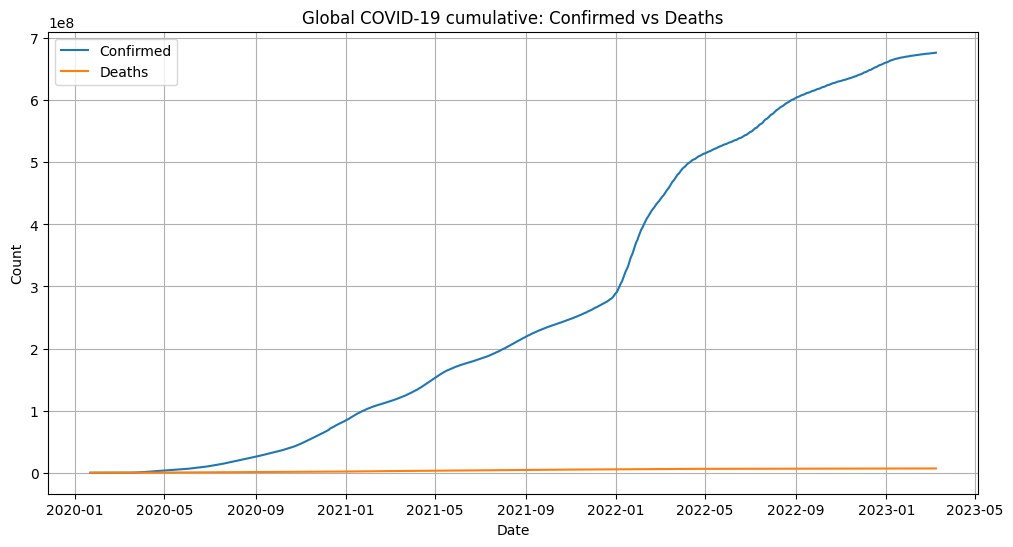

In [13]:
# Global totals
global_ts = country_ts.groupby('Date')[['Confirmed','Deaths']].sum().reset_index()
plt.figure()
plt.plot(global_ts['Date'], global_ts['Confirmed'], label='Confirmed')
plt.plot(global_ts['Date'], global_ts['Deaths'], label='Deaths')
plt.title('Global COVID-19 cumulative: Confirmed vs Deaths')
plt.legend()
plt.xlabel('Date'); plt.ylabel('Count'); plt.grid(True)
plt.show()


In [15]:
# Top 10 countries latest
latest = country_ts[country_ts['Date'] == country_ts['Date'].max()]
top10 = latest.sort_values('Confirmed', ascending=False).head(10)[['Country/Region','Confirmed','Deaths']]
print(top10.to_string(index=False))


Country/Region  Confirmed  Deaths
            US  103802702 1123836
         India   44690738  530779
        France   39866718  166176
       Germany   38249060  168935
        Brazil   37076053  699276
         Japan   33320438   72997
  Korea, South   30615522   34093
         Italy   25603510  188322
United Kingdom   24658705  220721
        Russia   22075858  388478


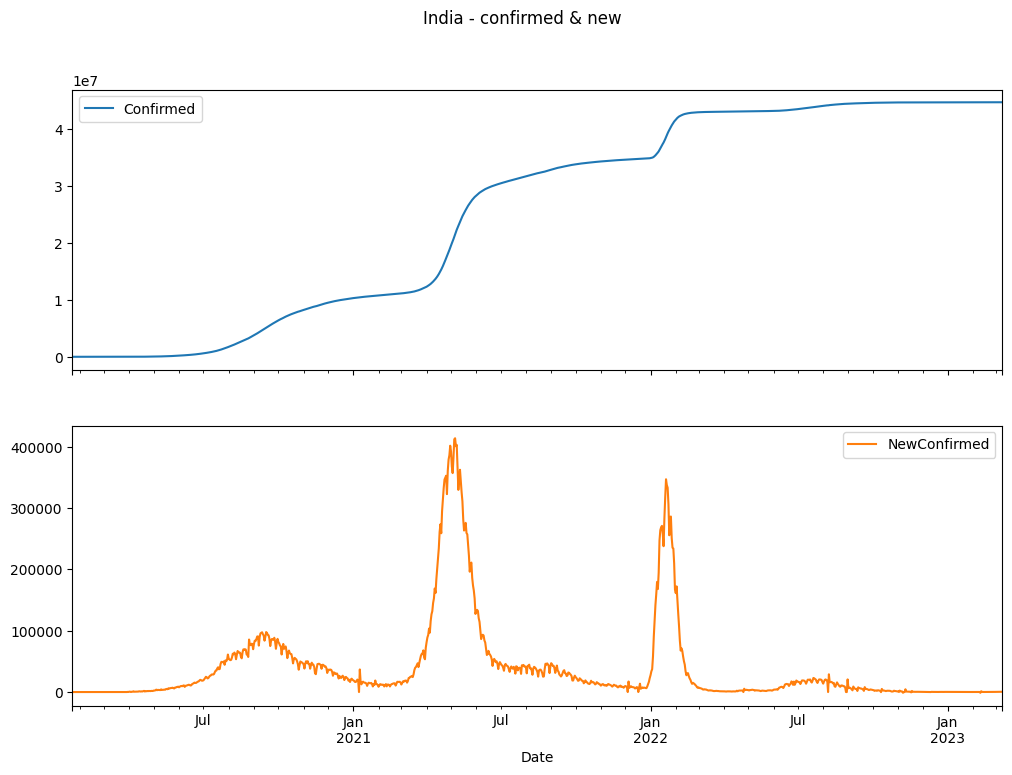

In [16]:
# Country time series (example: India)
country = "India"
ct = country_ts[country_ts['Country/Region']==country].set_index('Date')
ct[['Confirmed','NewConfirmed']].plot(subplots=True, figsize=(12,8), title=f"{country} - confirmed & new")
plt.show()


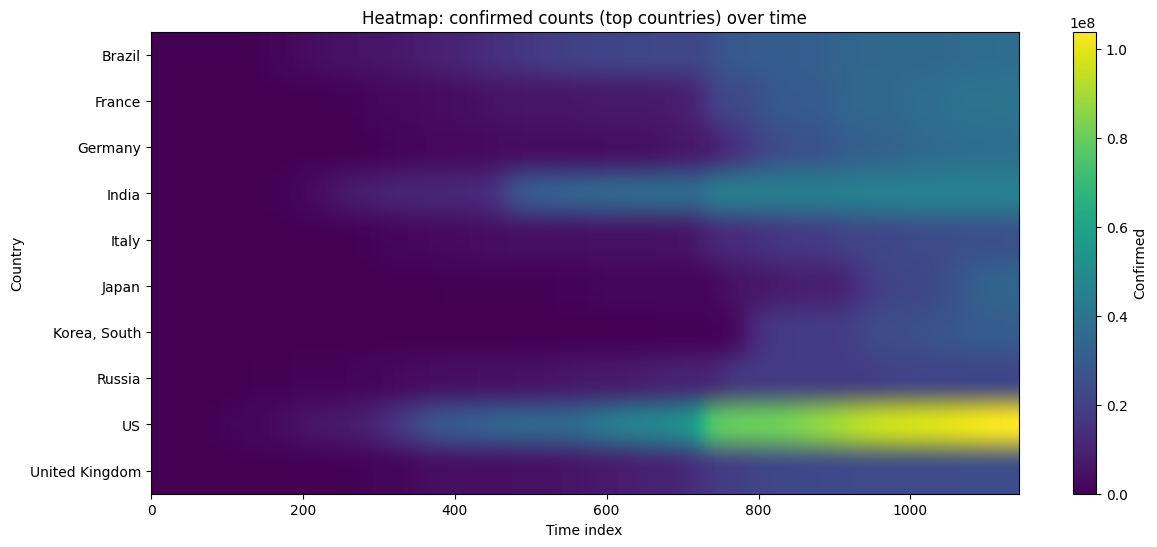

In [17]:
# Heatmap of top countries over time (pivot)
pivot = country_ts[country_ts['Country/Region'].isin(top10['Country/Region'])] \
            .pivot(index='Date', columns='Country/Region', values='Confirmed').fillna(0)
plt.figure(figsize=(14,6))
plt.imshow(pivot.T, aspect='auto')
plt.yticks(range(len(pivot.columns)), pivot.columns)
plt.title('Heatmap: confirmed counts (top countries) over time')
plt.xlabel('Time index'); plt.ylabel('Country')
plt.colorbar(label='Confirmed')
plt.show()


In [18]:
country_ts['NewConfirmed_7d'] = country_ts.groupby('Country/Region')['NewConfirmed'].transform(lambda x: x.rolling(7,1).mean())


In [19]:
# Identify any negative diffs or suspicious jumps
suspicious = country_ts[(country_ts['NewConfirmed'] < 0)]
print("Negative new cases rows:", len(suspicious))


Negative new cases rows: 171


In [20]:
# Save processed CSV
country_ts.to_csv("country_time_series_processed.csv", index=False)

# If using Drive:
country_ts.to_csv('/content/drive/MyDrive/COVID19_country_ts_processed.csv', index=False)

# Download locally
files.download("country_time_series_processed.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>